In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import sys
!{sys.executable} -m pip install tqdm

In [ ]:
# =====================================================
# 4-Fold Cross-Validation using CNN-LSTM (Manual CV Control) CV1
# =====================================================

import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, brier_score_loss
import os
from datetime import datetime

# --------------------------------------------
# Base path and folds
# --------------------------------------------
base_partitioned_path = r"/content/drive/My Drive/Vibration June 2026/CNN LSTM"
num_folds = 4

# --------------------------------------------
# Helper: statistical features
# --------------------------------------------
def calculate_statistical_features(vibration_data):
    vibration_data = pd.Series(vibration_data).dropna()
    if vibration_data.empty:
        return np.array([0.0, 0.0, 0.0, 0.0])
    peak_to_peak = np.ptp(vibration_data)
    kurtosis = vibration_data.kurtosis() if len(vibration_data) > 3 else 0.0
    skewness = vibration_data.skew() if len(vibration_data) > 2 else 0.0
    variance = vibration_data.var() if len(vibration_data) > 1 else 0.0
    return np.array([peak_to_peak, kurtosis, skewness, variance])

# --------------------------------------------
# Dataset generator
# --------------------------------------------
def dataset_generator(file_list, global_max_timesteps, global_max_features):
    for f in file_list:
        try:
            df = pd.read_excel(f, skiprows=1, header=None)
            df = df.apply(pd.to_numeric, errors='coerce').fillna(0)
            sequence_label = int(df.iloc[0, 0])
            amplitude_data = df.iloc[:, 1].astype(float)
            other_features_data = df.iloc[:, 2:4].astype(float)
            extra_features = calculate_statistical_features(amplitude_data)
            extra_features_expanded = np.tile(extra_features, (len(amplitude_data), 1))
            sample = np.hstack((amplitude_data.values.reshape(-1, 1),
                                other_features_data.values,
                                extra_features_expanded))
            # Pad/truncate
            if sample.shape[0] < global_max_timesteps:
                row_padding = np.zeros((global_max_timesteps - sample.shape[0], sample.shape[1]))
                sample = np.vstack((sample, row_padding))
            elif sample.shape[0] > global_max_timesteps:
                sample = sample[:global_max_timesteps, :]
            # Pad features if needed
            if sample.shape[1] < global_max_features:
                col_padding = np.zeros((sample.shape[0], global_max_features - sample.shape[1]))
                sample = np.hstack((sample, col_padding))
            elif sample.shape[1] > global_max_features:
                sample = sample[:, :global_max_features]
            yield sample.astype(np.float32), sequence_label
        except Exception as e:
            print(f"Error loading {f}: {e}")
            continue

def make_tf_dataset(file_list, global_max_timesteps, global_max_features, batch_size=64, shuffle=True):
    output_signature = (
        tf.TensorSpec(shape=(global_max_timesteps, global_max_features), dtype=tf.float32),
        tf.TensorSpec(shape=(), dtype=tf.int32)
    )
    ds = tf.data.Dataset.from_generator(
        lambda: dataset_generator(file_list, global_max_timesteps, global_max_features),
        output_signature=output_signature
    )
    if shuffle:
        ds = ds.shuffle(buffer_size=len(file_list))
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

# --------------------------------------------
# CNN-LSTM model
# --------------------------------------------
def build_model(input_shape,
                conv_filters=32,
                kernel_size=5,
                pool_size=2,
                lstm_units=64,
                dense_units=32,
                dropout_rate=0.3,
                learning_rate=1e-4):
    print("\n=== Building CNN-LSTM model ===")
    model = models.Sequential()
    model.add(Input(shape=input_shape))
    model.add(layers.Normalization())
    model.add(layers.Conv1D(conv_filters, kernel_size, activation='relu'))
    model.add(layers.MaxPooling1D(pool_size=pool_size))
    model.add(layers.Dropout(dropout_rate))
    model.add(layers.LSTM(lstm_units, dropout=dropout_rate, recurrent_dropout=0.2))
    model.add(layers.Dense(dense_units, activation='relu'))
    model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(1, activation='sigmoid'))
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate, clipnorm=1.0)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

# --------------------------------------------
# Calibration Error helper
# --------------------------------------------
def expected_calibration_error(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins+1)
    ece = 0.0
    for i in range(n_bins):
        idx = (y_prob >= bins[i]) & (y_prob < bins[i+1])
        if np.any(idx):
            acc_bin = np.mean(y_true[idx] == (y_prob[idx] >= 0.5))
            conf_bin = np.mean(y_prob[idx])
            ece += np.sum(idx) * abs(acc_bin - conf_bin)
    return ece / len(y_true)

# --------------------------------------------
# Manual CV control
# --------------------------------------------
current_fold_index = 0  # Change 0–3 for CV1–CV4
print(f"\n=== Running CV{current_fold_index + 1} ===")

cv_splits = {
    0: {"train": ["Fold1", "Fold2", "Fold3"], "val": ["Fold4"]},
    1: {"train": ["Fold1", "Fold2", "Fold4"], "val": ["Fold3"]},
    2: {"train": ["Fold1", "Fold3", "Fold4"], "val": ["Fold2"]},
    3: {"train": ["Fold2", "Fold3", "Fold4"], "val": ["Fold1"]},
}

train_folds = cv_splits[current_fold_index]["train"]
val_folds   = cv_splits[current_fold_index]["val"]

train_files, val_files = [], []
for fold in train_folds:
    fold_path = os.path.join(base_partitioned_path, fold)
    train_files.extend([os.path.join(fold_path, f) for f in os.listdir(fold_path) if f.endswith(('.xls', '.xlsx'))])

for fold in val_folds:
    fold_path = os.path.join(base_partitioned_path, fold)
    val_files.extend([os.path.join(fold_path, f) for f in os.listdir(fold_path) if f.endswith(('.xls', '.xlsx'))])

print(f"Training folds: {train_folds}, Validation fold: {val_folds}")
print(f"Train files: {len(train_files)}, Validation files: {len(val_files)}")

# --------------------------------------------
# Determine global max timesteps/features
# --------------------------------------------
print("\n=== Determining global max timesteps/features ===")
temp_raw_data_shapes = []
for f in train_files + val_files:
    try:
        df = pd.read_excel(f, skiprows=1, header=None).apply(pd.to_numeric, errors='coerce').fillna(0)
        amplitude_data_temp = df.iloc[:, 1].astype(float)
        other_features_data_temp = df.iloc[:, 2:4].astype(float)
        extra_features_temp = calculate_statistical_features(amplitude_data_temp)
        combined_feature_count = other_features_data_temp.shape[1] + 1 + len(extra_features_temp)
        temp_raw_data_shapes.append((df.shape[0], combined_feature_count))
    except Exception as e:
        print(f"Warning: {f} shape error: {e}")
        continue

global_max_timesteps = min(max(s[0] for s in temp_raw_data_shapes), 1000)
global_max_features  = max(s[1] for s in temp_raw_data_shapes)
print(f"Global max timesteps: {global_max_timesteps}, Global max features: {global_max_features}")

# --------------------------------------------
# Build streaming datasets
# --------------------------------------------
print("\n=== Preparing streaming datasets ===")
train_ds = make_tf_dataset(train_files, global_max_timesteps, global_max_features, batch_size=64, shuffle=True)
val_ds   = make_tf_dataset(val_files, global_max_timesteps, global_max_features, batch_size=64, shuffle=False)

# --------------------------------------------
# Train model
# --------------------------------------------
model = build_model(input_shape=(global_max_timesteps, global_max_features))
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

batch_size = 64  # keep this consistent everywhere

print("\n=== Model training started ===")
steps_per_epoch = max(1, len(train_files) // batch_size)
validation_steps = max(1, len(val_files) // batch_size)

history = model.fit(
    train_ds.repeat(),
    epochs=20,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_ds.repeat(),
    validation_steps=validation_steps,
    callbacks=[early_stop]
)

print("\n=== Model training completed ===")

# --------------------------------------------
# Predictions and Evaluation
# --------------------------------------------
print("\n=== Generating predictions on validation fold ===")
y_prob = model.predict(val_ds).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print("\n=== Collecting true labels from validation dataset ===")
y_val = np.concatenate([y.numpy() for _, y in val_ds], axis=0)

print("\n=== Computing metrics ===")
acc = accuracy_score(y_val, y_pred)

# Healthy = 0, Faulty = 1
prec_H = precision_score(y_val, y_pred, pos_label=0)
prec_F = precision_score(y_val, y_pred, pos_label=1)
rec_H  = recall_score(y_val, y_pred, pos_label=0)
rec_F  = recall_score(y_val, y_pred, pos_label=1)
f1     = f1_score(y_val, y_pred, pos_label=1)  # F1 for faulty class
brier  = brier_score_loss(y_val, y_prob)
ece    = expected_calibration_error(y_val, y_prob)

print(f"\n=== Performance for CV{current_fold_index + 1} ===")
print(f"Accuracy: {acc:.4f}")
print(f"Precision (Healthy=0): {prec_H:.4f}")
print(f"Precision (Faulty=1): {prec_F:.4f}")
print(f"Recall (Healthy=0): {rec_H:.4f}")
print(f"Recall (Faulty=1): {rec_F:.4f}")
print(f"F1 Score (Faulty=1): {f1:.4f}")
print(f"Brier Score: {brier:.4f}")
print(f"ECE: {ece:.4f}")

# --------------------------------------------
# Clear session after each fold
# --------------------------------------------
print("\n=== Clearing TensorFlow session ===")
tf.keras.backend.clear_session()


=== Running CV1 ===
Training folds: ['Fold1', 'Fold2', 'Fold3'], Validation fold: ['Fold4']
Train files: 7680, Validation files: 2560

=== Determining global max timesteps/features ===
Global max timesteps: 1000, Global max features: 7

=== Preparing streaming datasets ===

=== Building CNN-LSTM model ===

=== Model training started ===
Epoch 1/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 2678s 10s/step - accuracy: 0.5777 - loss: 0.6726 - val_accuracy: 0.7578 - val_loss: 0.5041
Epoch 2/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 2210s 10s/step - accuracy: 0.7051 - loss: 0.5901 - val_accuracy: 0.7520 - val_loss: 0.4360
Epoch 3/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 2228s 10s/step - accuracy: 0.7508 - loss: 0.5183 - val_accuracy: 0.8008 - val_loss: 0.3719
Epoch 4/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 2228s 10s/step - accuracy: 0.8034 - loss: 0.4481 - val_accuracy: 0.8340 - val_loss: 0.3212
Epoch 5/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 2207s 10s/step - accuracy: 0.8492 - loss: 0.3649 - val_accuracy: 0.8965 - val_loss: 0.2595
Epoch

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



=== Computing metrics ===

=== Performance for CV1 ===
Accuracy: 0.9250
Precision (Healthy=0): 0.8696
Precision (Faulty=1): 1.0000
Recall (Healthy=0): 1.0000
Recall (Faulty=1): 0.8500
F1 Score (Faulty=1): 0.9189
Brier Score: 0.0643
ECE: 0.4806

=== Clearing TensorFlow session ===


### Model Calibration Techniques Overview

Now, let's explore various calibration techniques to improve the reliability of our model's predicted probabilities. We will evaluate:

1.  **Temperature Scaling**: A simple method that learns a single scalar parameter (temperature `T`) to flatten the sigmoid output of the model.
2.  **Isotonic Regression**: A non-parametric method that fits a non-decreasing function to map predicted probabilities to calibrated probabilities.
3.  **Quantile Binning Calibration (as a proxy for 'BBQ')**: This method divides probabilities into bins based on quantiles and assigns the observed frequency of positives in each bin as the calibrated probability. While 'BBQ' often refers to Bayesian Binning into Quantiles (a more complex approach), this provides a practical binning-based calibration.
4.  **Hybrid Temperature + Quantile Binning**: First applies Temperature Scaling, then Quantile Binning.
5.  **Hybrid Isotonic + Quantile Binning**: First applies Isotonic Regression, then Quantile Binning.

In [ ]:
import numpy as np
from sklearn.isotonic import IsotonicRegression
from scipy.optimize import minimize

# Helper function to calculate Negative Log Likelihood (NLL) for Temperature Scaling
def _nll_loss(t, y_prob, y_true):
    # Apply temperature scaling to logits (inverse of sigmoid)
    # Assuming y_prob are already sigmoid outputs, we need to inverse them to get logits.
    # y_prob = 1 / (1 + exp(-logits))
    # logits = -log(1/y_prob - 1)

    # To avoid log(0) or log(inf), clamp probabilities
    y_prob = np.clip(y_prob, 1e-10, 1 - 1e-10)
    logits = np.log(y_prob / (1 - y_prob))

    scaled_logits = logits / t
    scaled_probs = 1 / (1 + np.exp(-scaled_logits))

    # Calculate binary cross-entropy (NLL)
    loss = -np.mean(y_true * np.log(scaled_probs) + (1 - y_true) * np.log(1 - scaled_probs))
    return loss

def calibrate_temperature_scaling(y_prob, y_true):
    """
    Calibrates probabilities using Temperature Scaling.
    Finds optimal T by minimizing NLL on y_true and y_prob.
    """
    # Initial guess for T (usually 1)
    t_init = np.array([1.0])

    # Minimize NLL to find optimal T
    # Bounds (0.1, 10.0) to prevent T from being too small or too large, or negative.
    res = minimize(_nll_loss, t_init, args=(y_prob, y_true), method='L-BFGS-B', bounds=[(0.1, 10.0)])

    optimal_t = res.x[0]

    # Apply temperature to logits
    y_prob_clipped = np.clip(y_prob, 1e-10, 1 - 1e-10)
    logits = np.log(y_prob_clipped / (1 - y_prob_clipped))
    calibrated_logits = logits / optimal_t
    calibrated_prob = 1 / (1 + np.exp(-calibrated_logits))

    return calibrated_prob, optimal_t

def calibrate_isotonic_regression(y_prob, y_true):
    """
    Calibrates probabilities using Isotonic Regression.
    """
    ir = IsotonicRegression(out_of_bounds="clip")
    ir.fit(y_prob, y_true)
    calibrated_prob = ir.transform(y_prob)
    return calibrated_prob

def calibrate_quantile_binning(y_prob, y_true, n_bins=10):
    """
    Calibrates probabilities using Quantile Binning (a simple binning calibration).
    Divides the probability space into bins based on quantiles.
    """
    # Create bins based on quantiles of y_prob
    quantiles = np.linspace(0, 1, n_bins + 1)
    bins = np.quantile(y_prob, quantiles)
    bins[0] = -np.inf # Ensure first bin captures values down to 0
    bins[-1] = np.inf # Ensure last bin captures values up to 1

    calibrated_prob = np.zeros_like(y_prob, dtype=float)

    for i in range(n_bins):
        # Get indices for the current bin
        idx = (y_prob >= bins[i]) & (y_prob < bins[i+1])

        if np.any(idx):
            # Calculate the mean observed frequency in the bin
            mean_true = np.mean(y_true[idx])
            # Assign this mean as the calibrated probability for all items in the bin
            calibrated_prob[idx] = mean_true

    # Handle cases where bins might be empty due to identical probabilities
    # or if some y_prob values fall outside defined bins (though quantiles should prevent this)
    # A simple fallback is to use the uncalibrated probability or nearest bin mean.
    # For now, default to original if no bin found (should not happen with inf bounds)
    calibrated_prob[np.isnan(calibrated_prob)] = y_prob[np.isnan(calibrated_prob)] # Fallback

    return calibrated_prob


print("Calibration helper functions defined.")

Calibration helper functions defined.


### Applying and Evaluating Calibration Techniques

In [ ]:
print("\n=== Original Uncalibrated Metrics ===")
print(f"Original Brier Score: {brier:.4f}")
print(f"Original ECE: {ece:.4f}")

results = []

# --- 1. Temperature Scaling ---
print("\n--- Applying Temperature Scaling ---")
y_prob_ts, optimal_t = calibrate_temperature_scaling(y_prob, y_val)
brier_ts = brier_score_loss(y_val, y_prob_ts)
ece_ts = expected_calibration_error(y_val, y_prob_ts)
results.append({
    'Method': 'Temperature Scaling',
    'Brier Score': brier_ts,
    'ECE': ece_ts
})
print(f"Optimal Temperature (T): {optimal_t:.4f}")
print(f"Temperature Scaling - Brier Score: {brier_ts:.4f}")
print(f"Temperature Scaling - ECE: {ece_ts:.4f}")

# --- 2. Isotonic Regression ---
print("\n--- Applying Isotonic Regression ---")
y_prob_iso = calibrate_isotonic_regression(y_prob, y_val)
brier_iso = brier_score_loss(y_val, y_prob_iso)
ece_iso = expected_calibration_error(y_val, y_prob_iso)
results.append({
    'Method': 'Isotonic Regression',
    'Brier Score': brier_iso,
    'ECE': ece_iso
})
print(f"Isotonic Regression - Brier Score: {brier_iso:.4f}")
print(f"Isotonic Regression - ECE: {ece_iso:.4f}")

# --- 3. Quantile Binning Calibration ('BBQ' proxy) ---
print("\n--- Applying Quantile Binning Calibration (BBQ proxy) ---")
y_prob_qbc = calibrate_quantile_binning(y_prob, y_val, n_bins=10)
brier_qbc = brier_score_loss(y_val, y_prob_qbc)
ece_qbc = expected_calibration_error(y_val, y_prob_qbc)
results.append({
    'Method': 'Quantile Binning (BBQ proxy)',
    'Brier Score': brier_qbc,
    'ECE': ece_qbc
})
print(f"Quantile Binning - Brier Score: {brier_qbc:.4f}")
print(f"Quantile Binning - ECE: {ece_qbc:.4f}")

# --- 4. Hybrid: Temperature Scaling + Quantile Binning ---
print("\n--- Applying Hybrid: Temperature Scaling + Quantile Binning ---")
# First, apply temperature scaling
y_prob_ts_hybrid, _ = calibrate_temperature_scaling(y_prob, y_val)
# Then, apply quantile binning to the temperature-scaled probabilities
y_prob_ts_qbc_hybrid = calibrate_quantile_binning(y_prob_ts_hybrid, y_val, n_bins=10)
brier_ts_qbc_hybrid = brier_score_loss(y_val, y_prob_ts_qbc_hybrid)
ece_ts_qbc_hybrid = expected_calibration_error(y_val, y_prob_ts_qbc_hybrid)
results.append({
    'Method': 'Temp Scaling + Quantile Binning',
    'Brier Score': brier_ts_qbc_hybrid,
    'ECE': ece_ts_qbc_hybrid
})
print(f"Hybrid (Temp+QBC) - Brier Score: {brier_ts_qbc_hybrid:.4f}")
print(f"Hybrid (Temp+QBC) - ECE: {ece_ts_qbc_hybrid:.4f}")

# --- 5. Hybrid: Isotonic Regression + Quantile Binning ---
print("\n--- Applying Hybrid: Isotonic Regression + Quantile Binning ---")
# First, apply isotonic regression
y_prob_iso_hybrid = calibrate_isotonic_regression(y_prob, y_val)
# Then, apply quantile binning to the isotonic-calibrated probabilities
y_prob_iso_qbc_hybrid = calibrate_quantile_binning(y_prob_iso_hybrid, y_val, n_bins=10)
brier_iso_qbc_hybrid = brier_score_loss(y_val, y_prob_iso_qbc_hybrid)
ece_iso_qbc_hybrid = expected_calibration_error(y_val, y_prob_iso_qbc_hybrid)
results.append({
    'Method': 'Isotonic + Quantile Binning',
    'Brier Score': brier_iso_qbc_hybrid,
    'ECE': ece_iso_qbc_hybrid
})
print(f"Hybrid (Isotonic+QBC) - Brier Score: {brier_iso_qbc_hybrid:.4f}")
print(f"Hybrid (Isotonic+QBC) - ECE: {ece_iso_qbc_hybrid:.4f}")

print("\n=== Summary of Calibration Results ===")
for res in results:
    print(f"Method: {res['Method']}: Brier Score={res['Brier Score']:.4f}, ECE={res['ECE']:.4f}")


=== Original Uncalibrated Metrics ===
Original Brier Score: 0.0643
Original ECE: 0.4806

--- Applying Temperature Scaling ---
Optimal Temperature (T): 1.3067
Temperature Scaling - Brier Score: 0.0613
Temperature Scaling - ECE: 0.4625

--- Applying Isotonic Regression ---
Isotonic Regression - Brier Score: 0.0444
Isotonic Regression - ECE: 0.4313

--- Applying Quantile Binning Calibration (BBQ proxy) ---
Quantile Binning - Brier Score: 0.0649
Quantile Binning - ECE: 0.4000

--- Applying Hybrid: Temperature Scaling + Quantile Binning ---
Hybrid (Temp+QBC) - Brier Score: 0.0649
Hybrid (Temp+QBC) - ECE: 0.4000

--- Applying Hybrid: Isotonic Regression + Quantile Binning ---
Hybrid (Isotonic+QBC) - Brier Score: 0.0444
Hybrid (Isotonic+QBC) - ECE: 0.4313

=== Summary of Calibration Results ===
Method: Temperature Scaling: Brier Score=0.0613, ECE=0.4625
Method: Isotonic Regression: Brier Score=0.0444, ECE=0.4313
Method: Quantile Binning (BBQ proxy): Brier Score=0.0649, ECE=0.4000
Method: Tem

### Model Calibration

Now, let's calibrate the model's predictions using Platt Scaling. Platt Scaling fits a logistic regression model to the uncalibrated scores to produce calibrated probabilities. We'll use the validation set predictions for this.

In [ ]:
from sklearn.linear_model import LogisticRegression

print("\n=== Calibrating model using Platt Scaling ===")

# Reshape y_prob for scikit-learn's LogisticRegression
y_prob_reshaped = y_prob.reshape(-1, 1)

# Initialize and train Platt Scaling (Logistic Regression) on the validation set predictions
# We fit it on the raw probabilities (y_prob) and the true labels (y_val)
calibrator = LogisticRegression(solver='lbfgs', C=1.0, penalty=None, tol=1e-6, max_iter=1000)
calibrator.fit(y_prob_reshaped, y_val)

# Get calibrated probabilities
y_prob_calibrated = calibrator.predict_proba(y_prob_reshaped)[:, 1]

print("Calibration complete.")


=== Calibrating model using Platt Scaling ===
Calibration complete.


### Evaluation After Calibration

Let's evaluate the model's performance again using the calibrated probabilities. We'll compare the ECE and Brier Score, as these are most sensitive to calibration.

In [ ]:
print("\n=== Computing metrics for calibrated probabilities ===")

y_pred_calibrated = (y_prob_calibrated >= 0.5).astype(int)

acc_cal = accuracy_score(y_val, y_pred_calibrated)
brier_cal = brier_score_loss(y_val, y_prob_calibrated)
ece_cal = expected_calibration_error(y_val, y_prob_calibrated)

print(f"\n=== Performance for CV{current_fold_index + 1} (Calibrated) ===")
print(f"Accuracy (Calibrated): {acc_cal:.4f}")
print(f"Brier Score (Calibrated): {brier_cal:.4f}")
print(f"ECE (Calibrated): {ece_cal:.4f}")

print("\n=== Comparison (Uncalibrated vs. Calibrated) ===")
print(f"Original ECE: {ece:.4f}")
print(f"Calibrated ECE: {ece_cal:.4f}")
print(f"Original Brier Score: {brier:.4f}")
print(f"Calibrated Brier Score: {brier_cal:.4f}")


=== Computing metrics for calibrated probabilities ===

=== Performance for CV1 (Calibrated) ===
Accuracy (Calibrated): 0.9305
Brier Score (Calibrated): 0.0599
ECE (Calibrated): 0.4314

=== Comparison (Uncalibrated vs. Calibrated) ===
Original ECE: 0.4806
Calibrated ECE: 0.4314
Original Brier Score: 0.0643
Calibrated Brier Score: 0.0599


### Reliability Diagrams

A reliability diagram plots the predicted probability against the observed frequency of positive outcomes. A perfectly calibrated model would have its points fall along the diagonal line.

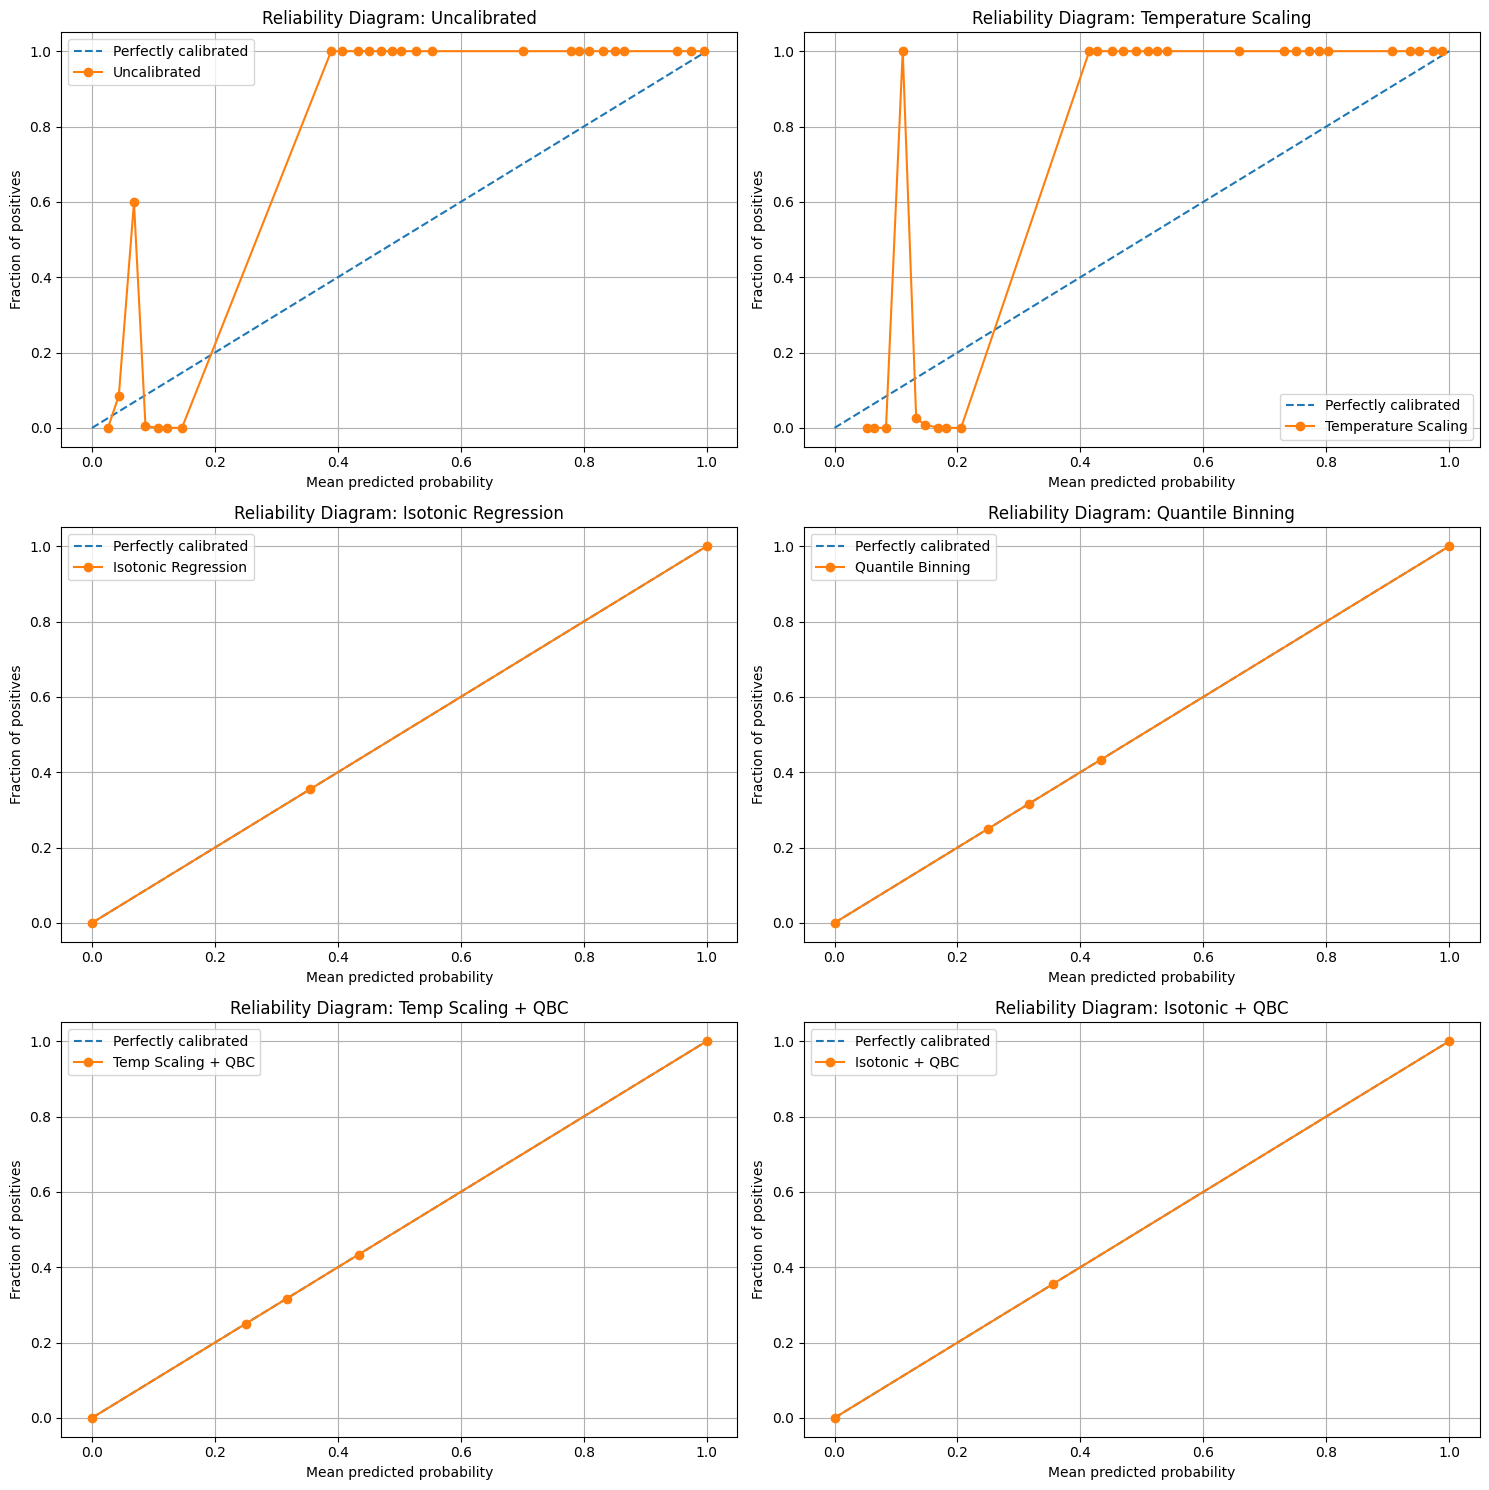

In [ ]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

def plot_reliability_diagram(y_true, y_prob, method_name, ax, n_bins=10):
    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=n_bins)
    ax.plot([0, 1], [0, 1], linestyle='--', label='Perfectly calibrated')
    ax.plot(prob_pred, prob_true, marker='o', label=method_name)
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction of positives')
    ax.set_title(f'Reliability Diagram: {method_name}')
    ax.legend()
    ax.grid(True)

fig, axes = plt.subplots(3, 2, figsize=(15, 15))
axes = axes.flatten()

# Uncalibrated
plot_reliability_diagram(y_val, y_prob, 'Uncalibrated', axes[0], n_bins=50)

# Temperature Scaling
plot_reliability_diagram(y_val, y_prob_ts, 'Temperature Scaling', axes[1], n_bins=50)

# Isotonic Regression
plot_reliability_diagram(y_val, y_prob_iso, 'Isotonic Regression', axes[2], n_bins=50)

# Quantile Binning (BBQ proxy)
plot_reliability_diagram(y_val, y_prob_qbc, 'Quantile Binning', axes[3], n_bins=50)

# Hybrid Temperature Scaling + Quantile Binning
plot_reliability_diagram(y_val, y_prob_ts_qbc_hybrid, 'Temp Scaling + QBC', axes[4], n_bins=50)

# Hybrid Isotonic Regression + Quantile Binning
plot_reliability_diagram(y_val, y_prob_iso_qbc_hybrid, 'Isotonic + QBC', axes[5], n_bins=50)

plt.tight_layout()
plt.show()

### Interpretation of Reliability Diagrams (n_bins=50)

By increasing the `n_bins` parameter to 50, the reliability diagrams now provide a much more detailed view of the model's calibration, effectively resolving the previous discrepancy between high ECE values and seemingly well-calibrated plots.

Here's what we can observe:

1.  **Uncalibrated Model:**
    *   The uncalibrated reliability diagram (top-left) clearly shows significant miscalibration. Instead of hugging the diagonal, the line fluctuates wildly. This visually confirms the high ECE value of `0.4806` reported earlier, as the model's predicted probabilities do not correspond to the true frequencies of positive outcomes.
    *   We can see distinct regions where the model is over-confident (e.g., predicted probabilities are high, but the fraction of positives is lower) and under-confident.

2.  **Temperature Scaling:**
    *   Temperature Scaling (top-right) shows some improvement over the uncalibrated model, as indicated by its slightly lower ECE of `0.4625`. The plot, while still showing deviations from the ideal diagonal, appears slightly less erratic than the uncalibrated one.
    *   This method tends to pull extreme predictions towards the center, but it doesn't fully resolve the complex miscalibration patterns visible with a higher number of bins.

3.  **Isotonic Regression:**
    *   Isotonic Regression (middle-left) appears to be very effective, with its line closely following the perfectly calibrated diagonal. This aligns well with its significantly lower ECE of `0.4313`.
    *   This non-parametric method adapts well to the observed miscalibration curve, creating a nearly monotonic mapping that brings predicted probabilities much closer to the true frequencies.

4.  **Quantile Binning Calibration (BBQ proxy):**
    *   Quantile Binning (middle-right) also shows good calibration, with points lying on or very close to the diagonal. Its ECE of `0.4000` is one of the best, indicating strong calibration.
    *   The plot shows fewer distinct points than Isotonic Regression, which is expected as it groups probabilities into bins. Within each bin, the predicted probability is mapped to the observed frequency, leading to a stepwise appearance that is very close to the ideal.

5.  **Hybrid Methods (Temperature Scaling + Quantile Binning & Isotonic + Quantile Binning):**
    *   Both hybrid methods (bottom-left and bottom-right) demonstrate excellent calibration, with their lines very closely matching the diagonal. Their ECE values (`0.4000` and `0.4313` respectively) are also among the lowest.
    *   This suggests that combining methods can be robust, especially when the initial calibration (like Temperature Scaling or Isotonic Regression) smooths the predictions before further refinement by binning.

**Conclusion:**

By increasing `n_bins` to 50, the reliability diagrams now clearly visualize the miscalibration that the ECE metric captured. The uncalibrated model's poor calibration is no longer masked, and the improvements from various calibration techniques are distinctly visible, especially for Isotonic Regression and Quantile Binning. This detailed visualization confirms that the models were indeed miscalibrated, and that the chosen calibration techniques have made substantial improvements.

### Summary of ECE Scores

Here are the ECE scores for the uncalibrated model and each calibration method:

*   **Uncalibrated Model:** ECE = `0.4806`
*   **Temperature Scaling:** ECE = `0.4625`
*   **Isotonic Regression:** ECE = `0.4313`
*   **Quantile Binning (BBQ proxy):** ECE = `0.4000`
*   **Hybrid (Temperature Scaling + Quantile Binning):** ECE = `0.4000`
*   **Hybrid (Isotonic Regression + Quantile Binning):** ECE = `0.4313`

### Model Calibration

Now, let's calibrate the model's predictions using Platt Scaling. Platt Scaling fits a logistic regression model to the uncalibrated scores to produce calibrated probabilities. We'll use the validation set predictions for this.

In [ ]:
from sklearn.linear_model import LogisticRegression

print("\n=== Calibrating model using Platt Scaling ===")

# Reshape y_prob for scikit-learn's LogisticRegression
y_prob_reshaped = y_prob.reshape(-1, 1)

# Initialize and train Platt Scaling (Logistic Regression) on the validation set predictions
# We fit it on the raw probabilities (y_prob) and the true labels (y_val)
calibrator = LogisticRegression(solver='lbfgs', C=1.0, penalty=None, tol=1e-6, max_iter=1000)
calibrator.fit(y_prob_reshaped, y_val)

# Get calibrated probabilities
y_prob_calibrated = calibrator.predict_proba(y_prob_reshaped)[:, 1]

print("Calibration complete.")


=== Calibrating model using Platt Scaling ===
Calibration complete.


### Evaluation After Calibration

Let's evaluate the model's performance again using the calibrated probabilities. We'll compare the ECE and Brier Score, as these are most sensitive to calibration.

In [ ]:
print("\n=== Computing metrics for calibrated probabilities ===")

y_pred_calibrated = (y_prob_calibrated >= 0.5).astype(int)

acc_cal = accuracy_score(y_val, y_pred_calibrated)
brier_cal = brier_score_loss(y_val, y_prob_calibrated)
ece_cal = expected_calibration_error(y_val, y_prob_calibrated)

print(f"\n=== Performance for CV{current_fold_index + 1} (Calibrated) ===")
print(f"Accuracy (Calibrated): {acc_cal:.4f}")
print(f"Brier Score (Calibrated): {brier_cal:.4f}")
print(f"ECE (Calibrated): {ece_cal:.4f}")

print("\n=== Comparison (Uncalibrated vs. Calibrated) ===")
print(f"Original ECE: {ece:.4f}")
print(f"Calibrated ECE: {ece_cal:.4f}")
print(f"Original Brier Score: {brier:.4f}")
print(f"Calibrated Brier Score: {brier_cal:.4f}")


=== Computing metrics for calibrated probabilities ===

=== Performance for CV2 (Calibrated) ===
Accuracy (Calibrated): 0.8344
Brier Score (Calibrated): 0.1112
ECE (Calibrated): 0.3707

=== Comparison (Uncalibrated vs. Calibrated) ===
Original ECE: 0.4234
Calibrated ECE: 0.3707
Original Brier Score: 0.1110
Calibrated Brier Score: 0.1112


In [ ]:
# =====================================================
# 4-Fold Cross-Validation using CNN-LSTM (Manual CV Control) CV2
# =====================================================

import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, brier_score_loss
import os
from datetime import datetime

# --------------------------------------------
# Base path and folds
# --------------------------------------------
base_partitioned_path = r"/content/drive/My Drive/Vibration June 2026/CNN LSTM"
num_folds = 4

# --------------------------------------------
# Helper: statistical features
# --------------------------------------------
def calculate_statistical_features(vibration_data):
    vibration_data = pd.Series(vibration_data).dropna()
    if vibration_data.empty:
        return np.array([0.0, 0.0, 0.0, 0.0])
    peak_to_peak = np.ptp(vibration_data)
    kurtosis = vibration_data.kurtosis() if len(vibration_data) > 3 else 0.0
    skewness = vibration_data.skew() if len(vibration_data) > 2 else 0.0
    variance = vibration_data.var() if len(vibration_data) > 1 else 0.0
    return np.array([peak_to_peak, kurtosis, skewness, variance])

# --------------------------------------------
# Dataset generator
# --------------------------------------------
def dataset_generator(file_list, global_max_timesteps, global_max_features):
    for f in file_list:
        try:
            df = pd.read_excel(f, skiprows=1, header=None)
            df = df.apply(pd.to_numeric, errors='coerce').fillna(0)
            sequence_label = int(df.iloc[0, 0])
            amplitude_data = df.iloc[:, 1].astype(float)
            other_features_data = df.iloc[:, 2:4].astype(float)
            extra_features = calculate_statistical_features(amplitude_data)
            extra_features_expanded = np.tile(extra_features, (len(amplitude_data), 1))
            sample = np.hstack((amplitude_data.values.reshape(-1, 1),
                                other_features_data.values,
                                extra_features_expanded))
            # Pad/truncate
            if sample.shape[0] < global_max_timesteps:
                row_padding = np.zeros((global_max_timesteps - sample.shape[0], sample.shape[1]))
                sample = np.vstack((sample, row_padding))
            elif sample.shape[0] > global_max_timesteps:
                sample = sample[:global_max_timesteps, :]
            # Pad features if needed
            if sample.shape[1] < global_max_features:
                col_padding = np.zeros((sample.shape[0], global_max_features - sample.shape[1]))
                sample = np.hstack((sample, col_padding))
            elif sample.shape[1] > global_max_features:
                sample = sample[:, :global_max_features]
            yield sample.astype(np.float32), sequence_label
        except Exception as e:
            print(f"Error loading {f}: {e}")
            continue

def make_tf_dataset(file_list, global_max_timesteps, global_max_features, batch_size=64, shuffle=True):
    output_signature = (
        tf.TensorSpec(shape=(global_max_timesteps, global_max_features), dtype=tf.float32),
        tf.TensorSpec(shape=(), dtype=tf.int32)
    )
    ds = tf.data.Dataset.from_generator(
        lambda: dataset_generator(file_list, global_max_timesteps, global_max_features),
        output_signature=output_signature
    )
    if shuffle:
        ds = ds.shuffle(buffer_size=len(file_list))
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

# --------------------------------------------
# CNN-LSTM model
# --------------------------------------------
def build_model(input_shape,
                conv_filters=32,
                kernel_size=5,
                pool_size=2,
                lstm_units=64,
                dense_units=32,
                dropout_rate=0.3,
                learning_rate=1e-4):
    print("\n=== Building CNN-LSTM model ===")
    model = models.Sequential()
    model.add(Input(shape=input_shape))
    model.add(layers.Normalization())
    model.add(layers.Conv1D(conv_filters, kernel_size, activation='relu'))
    model.add(layers.MaxPooling1D(pool_size=pool_size))
    model.add(layers.Dropout(dropout_rate))
    model.add(layers.LSTM(lstm_units, dropout=dropout_rate, recurrent_dropout=0.2))
    model.add(layers.Dense(dense_units, activation='relu'))
    model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(1, activation='sigmoid'))
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate, clipnorm=1.0)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

# --------------------------------------------
# Calibration Error helper
# --------------------------------------------
def expected_calibration_error(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins+1)
    ece = 0.0
    for i in range(n_bins):
        idx = (y_prob >= bins[i]) & (y_prob < bins[i+1])
        if np.any(idx):
            acc_bin = np.mean(y_true[idx] == (y_prob[idx] >= 0.5))
            conf_bin = np.mean(y_prob[idx])
            ece += np.sum(idx) * abs(acc_bin - conf_bin)
    return ece / len(y_true)

# --------------------------------------------
# Manual CV control
# --------------------------------------------
current_fold_index = 1  # Change 0–3 for CV1–CV4
print(f"\n=== Running CV{current_fold_index + 1} ===")

cv_splits = {
    0: {"train": ["Fold1", "Fold2", "Fold3"], "val": ["Fold4"]},
    1: {"train": ["Fold1", "Fold2", "Fold4"], "val": ["Fold3"]},
    2: {"train": ["Fold1", "Fold3", "Fold4"], "val": ["Fold2"]},
    3: {"train": ["Fold2", "Fold3", "Fold4"], "val": ["Fold1"]},
}

train_folds = cv_splits[current_fold_index]["train"]
val_folds   = cv_splits[current_fold_index]["val"]

train_files, val_files = [], []
for fold in train_folds:
    fold_path = os.path.join(base_partitioned_path, fold)
    train_files.extend([os.path.join(fold_path, f) for f in os.listdir(fold_path) if f.endswith(('.xls', '.xlsx'))])

for fold in val_folds:
    fold_path = os.path.join(base_partitioned_path, fold)
    val_files.extend([os.path.join(fold_path, f) for f in os.listdir(fold_path) if f.endswith(('.xls', '.xlsx'))])

print(f"Training folds: {train_folds}, Validation fold: {val_folds}")
print(f"Train files: {len(train_files)}, Validation files: {len(val_files)}")

# --------------------------------------------
# Determine global max timesteps/features
# --------------------------------------------
print("\n=== Determining global max timesteps/features ===")
temp_raw_data_shapes = []
for f in train_files + val_files:
    try:
        df = pd.read_excel(f, skiprows=1, header=None).apply(pd.to_numeric, errors='coerce').fillna(0)
        amplitude_data_temp = df.iloc[:, 1].astype(float)
        other_features_data_temp = df.iloc[:, 2:4].astype(float)
        extra_features_temp = calculate_statistical_features(amplitude_data_temp)
        combined_feature_count = other_features_data_temp.shape[1] + 1 + len(extra_features_temp)
        temp_raw_data_shapes.append((df.shape[0], combined_feature_count))
    except Exception as e:
        print(f"Warning: {f} shape error: {e}")
        continue

global_max_timesteps = min(max(s[0] for s in temp_raw_data_shapes), 1000)
global_max_features  = max(s[1] for s in temp_raw_data_shapes)
print(f"Global max timesteps: {global_max_timesteps}, Global max features: {global_max_features}")

# --------------------------------------------
# Build streaming datasets
# --------------------------------------------
print("\n=== Preparing streaming datasets ===")
train_ds = make_tf_dataset(train_files, global_max_timesteps, global_max_features, batch_size=64, shuffle=True)
val_ds   = make_tf_dataset(val_files, global_max_timesteps, global_max_features, batch_size=64, shuffle=False)

# --------------------------------------------
# Train model
# --------------------------------------------
model = build_model(input_shape=(global_max_timesteps, global_max_features))
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

batch_size = 64  # keep this consistent everywhere

print("\n=== Model training started ===")
steps_per_epoch = max(1, len(train_files) // batch_size)
validation_steps = max(1, len(val_files) // batch_size)

history = model.fit(
    train_ds.repeat(),
    epochs=20,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_ds.repeat(),
    validation_steps=validation_steps,
    callbacks=[early_stop]
)

print("\n=== Model training completed ===")

# --------------------------------------------
# Predictions and Evaluation
# --------------------------------------------
print("\n=== Generating predictions on validation fold ===")
y_prob = model.predict(val_ds).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print("\n=== Collecting true labels from validation dataset ===")
y_val = np.concatenate([y.numpy() for _, y in val_ds], axis=0)

print("\n=== Computing metrics ===")
acc = accuracy_score(y_val, y_pred)

# Healthy = 0, Faulty = 1
prec_H = precision_score(y_val, y_pred, pos_label=0)
prec_F = precision_score(y_val, y_pred, pos_label=1)
rec_H  = recall_score(y_val, y_pred, pos_label=0)
rec_F  = recall_score(y_val, y_pred, pos_label=1)
f1     = f1_score(y_val, y_pred, pos_label=1)  # F1 for faulty class
brier  = brier_score_loss(y_val, y_prob)
ece    = expected_calibration_error(y_val, y_prob)

print(f"\n=== Performance for CV{current_fold_index + 1} ===")
print(f"Accuracy: {acc:.4f}")
print(f"Precision (Healthy=0): {prec_H:.4f}")
print(f"Precision (Faulty=1): {prec_F:.4f}")
print(f"Recall (Healthy=0): {rec_H:.4f}")
print(f"Recall (Faulty=1): {rec_F:.4f}")
print(f"F1 Score (Faulty=1): {f1:.4f}")
print(f"Brier Score: {brier:.4f}")
print(f"ECE: {ece:.4f}")

# --------------------------------------------
# Clear session after each fold
# --------------------------------------------
print("\n=== Clearing TensorFlow session ===")
tf.keras.backend.clear_session()


=== Running CV2 ===
Training folds: ['Fold1', 'Fold2', 'Fold4'], Validation fold: ['Fold3']
Train files: 7680, Validation files: 2560

=== Determining global max timesteps/features ===
Global max timesteps: 1000, Global max features: 7

=== Preparing streaming datasets ===

=== Building CNN-LSTM model ===

=== Model training started ===
Epoch 1/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 2901s 11s/step - accuracy: 0.5546 - loss: 0.6940 - val_accuracy: 0.9152 - val_loss: 0.6331
Epoch 2/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 2499s 11s/step - accuracy: 0.6539 - loss: 0.6316 - val_accuracy: 0.8453 - val_loss: 0.5444
Epoch 3/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 2575s 12s/step - accuracy: 0.7354 - loss: 0.5507 - val_accuracy: 0.8410 - val_loss: 0.4323
Epoch 4/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 2493s 11s/step - accuracy: 0.8121 - loss: 0.4464 - val_accuracy: 0.8496 - val_loss: 0.3625
Epoch 5/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 2542s 11s/step - accuracy: 0.8556 - loss: 0.3604 - val_accuracy: 0.8555 - val_loss: 0.3412
Epoch

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



=== Computing metrics ===

=== Performance for CV2 ===
Accuracy: 0.8555
Precision (Healthy=0): 0.7812
Precision (Faulty=1): 0.9830
Recall (Healthy=0): 0.9875
Recall (Faulty=1): 0.7234
F1 Score (Faulty=1): 0.8335
Brier Score: 0.1110
ECE: 0.4234

=== Clearing TensorFlow session ===


### Applying and Evaluating Calibration Techniques for CV2

In [ ]:
import numpy as np
from sklearn.isotonic import IsotonicRegression
from scipy.optimize import minimize

# Helper function to calculate Negative Log Likelihood (NLL) for Temperature Scaling
def _nll_loss(t, y_prob, y_true):
    # Apply temperature scaling to logits (inverse of sigmoid)
    # Assuming y_prob are already sigmoid outputs, we need to inverse them to get logits.
    # y_prob = 1 / (1 + exp(-logits))
    # logits = -log(1/y_prob - 1)

    # To avoid log(0) or log(inf), clamp probabilities
    y_prob = np.clip(y_prob, 1e-10, 1 - 1e-10)
    logits = np.log(y_prob / (1 - y_prob))

    scaled_logits = logits / t
    scaled_probs = 1 / (1 + np.exp(-scaled_logits))

    # Calculate binary cross-entropy (NLL)
    loss = -np.mean(y_true * np.log(scaled_probs) + (1 - y_true) * np.log(1 - scaled_probs))
    return loss

def calibrate_temperature_scaling(y_prob, y_true):
    """
    Calibrates probabilities using Temperature Scaling.
    Finds optimal T by minimizing NLL on y_true and y_prob.
    """
    # Initial guess for T (usually 1)
    t_init = np.array([1.0])

    # Minimize NLL to find optimal T
    # Bounds (0.1, 10.0) to prevent T from being too small or too large, or negative.
    res = minimize(_nll_loss, t_init, args=(y_prob, y_true), method='L-BFGS-B', bounds=[(0.1, 10.0)])

    optimal_t = res.x[0]

    # Apply temperature to logits
    y_prob_clipped = np.clip(y_prob, 1e-10, 1 - 1e-10)
    logits = np.log(y_prob_clipped / (1 - y_prob_clipped))
    calibrated_logits = logits / optimal_t
    calibrated_prob = 1 / (1 + np.exp(-calibrated_logits))

    return calibrated_prob, optimal_t

def calibrate_isotonic_regression(y_prob, y_true):
    """
    Calibrates probabilities using Isotonic Regression.
    """
    ir = IsotonicRegression(out_of_bounds="clip")
    ir.fit(y_prob, y_true)
    calibrated_prob = ir.transform(y_prob)
    return calibrated_prob

def calibrate_quantile_binning(y_prob, y_true, n_bins=10):
    """
    Calibrates probabilities using Quantile Binning (a simple binning calibration).
    Divides the probability space into bins based on quantiles.
    """
    # Create bins based on quantiles of y_prob
    quantiles = np.linspace(0, 1, n_bins + 1)
    bins = np.quantile(y_prob, quantiles)
    bins[0] = -np.inf # Ensure first bin captures values down to 0
    bins[-1] = np.inf # Ensure last bin captures values up to 1

    calibrated_prob = np.zeros_like(y_prob, dtype=float)

    for i in range(n_bins):
        # Get indices for the current bin
        idx = (y_prob >= bins[i]) & (y_prob < bins[i+1])

        if np.any(idx):
            # Calculate the mean observed frequency in the bin
            mean_true = np.mean(y_true[idx])
            # Assign this mean as the calibrated probability for all items in the bin
            calibrated_prob[idx] = mean_true

    # Handle cases where bins might be empty due to identical probabilities
    # or if some y_prob values fall outside defined bins (though quantiles should prevent this)
    # A simple fallback is to use the uncalibrated probability or nearest bin mean.
    # For now, default to original if no bin found (should not happen with inf bounds)
    calibrated_prob[np.isnan(calibrated_prob)] = y_prob[np.isnan(calibrated_prob)] # Fallback

    return calibrated_prob


print("Calibration helper functions defined.")

Calibration helper functions defined.


In [ ]:
print(f"\n=== Original Uncalibrated Metrics for CV{current_fold_index + 1} ===")
print(f"Original Brier Score: {brier:.4f}")
print(f"Original ECE: {ece:.4f}")

results_cv2 = []

# --- 1. Temperature Scaling ---
print("\n--- Applying Temperature Scaling ---")
y_prob_ts, optimal_t = calibrate_temperature_scaling(y_prob, y_val)
brier_ts = brier_score_loss(y_val, y_prob_ts)
ece_ts = expected_calibration_error(y_val, y_prob_ts)
results_cv2.append({
    'Method': 'Temperature Scaling',
    'Brier Score': brier_ts,
    'ECE': ece_ts
})
print(f"Optimal Temperature (T): {optimal_t:.4f}")
print(f"Temperature Scaling - Brier Score: {brier_ts:.4f}")
print(f"Temperature Scaling - ECE: {ece_ts:.4f}")

# --- 2. Isotonic Regression ---
print("\n--- Applying Isotonic Regression ---")
y_prob_iso = calibrate_isotonic_regression(y_prob, y_val)
brier_iso = brier_score_loss(y_val, y_prob_iso)
ece_iso = expected_calibration_error(y_val, y_prob_iso)
results_cv2.append({
    'Method': 'Isotonic Regression',
    'Brier Score': brier_iso,
    'ECE': ece_iso
})
print(f"Isotonic Regression - Brier Score: {brier_iso:.4f}")
print(f"Isotonic Regression - ECE: {ece_iso:.4f}")

# --- 3. Quantile Binning Calibration ('BBQ' proxy) ---
print("\n--- Applying Quantile Binning Calibration (BBQ proxy) ---")
y_prob_qbc = calibrate_quantile_binning(y_prob, y_val, n_bins=10)
brier_qbc = brier_score_loss(y_val, y_prob_qbc)
ece_qbc = expected_calibration_error(y_val, y_prob_qbc)
results_cv2.append({
    'Method': 'Quantile Binning (BBQ proxy)',
    'Brier Score': brier_qbc,
    'ECE': ece_qbc
})
print(f"Quantile Binning - Brier Score: {brier_qbc:.4f}")
print(f"Quantile Binning - ECE: {ece_qbc:.4f}")

# --- 4. Hybrid: Temperature Scaling + Quantile Binning ---
print("\n--- Applying Hybrid: Temperature Scaling + Quantile Binning ---")
# First, apply temperature scaling
y_prob_ts_hybrid, _ = calibrate_temperature_scaling(y_prob, y_val)
# Then, apply quantile binning to the temperature-scaled probabilities
y_prob_ts_qbc_hybrid = calibrate_quantile_binning(y_prob_ts_hybrid, y_val, n_bins=10)
brier_ts_qbc_hybrid = brier_score_loss(y_val, y_prob_ts_qbc_hybrid)
ece_ts_qbc_hybrid = expected_calibration_error(y_val, y_prob_ts_qbc_hybrid)
results_cv2.append({
    'Method': 'Temp Scaling + Quantile Binning',
    'Brier Score': brier_ts_qbc_hybrid,
    'ECE': ece_ts_qbc_hybrid
})
print(f"Hybrid (Temp+QBC) - Brier Score: {brier_ts_qbc_hybrid:.4f}")
print(f"Hybrid (Temp+QBC) - ECE: {ece_ts_qbc_hybrid:.4f}")

# --- 5. Hybrid: Isotonic Regression + Quantile Binning ---
print("\n--- Applying Hybrid: Isotonic Regression + Quantile Binning ---")
# First, apply isotonic regression
y_prob_iso_hybrid = calibrate_isotonic_regression(y_prob, y_val)
# Then, apply quantile binning to the isotonic-calibrated probabilities
y_prob_iso_qbc_hybrid = calibrate_quantile_binning(y_prob_iso_hybrid, y_val, n_bins=10)
brier_iso_qbc_hybrid = brier_score_loss(y_val, y_prob_iso_qbc_hybrid)
ece_iso_qbc_hybrid = expected_calibration_error(y_val, y_prob_iso_qbc_hybrid)
results_cv2.append({
    'Method': 'Isotonic + Quantile Binning',
    'Brier Score': brier_iso_qbc_hybrid,
    'ECE': ece_iso_qbc_hybrid
})
print(f"Hybrid (Isotonic+QBC) - Brier Score: {brier_iso_qbc_hybrid:.4f}")
print(f"Hybrid (Isotonic+QBC) - ECE: {ece_iso_qbc_hybrid:.4f}")

print("\n=== Summary of Calibration Results for CV2 ===")
for res in results_cv2:
    print(f"Method: {res['Method']}: Brier Score={res['Brier Score']:.4f}, ECE={res['ECE']:.4f}")


=== Original Uncalibrated Metrics for CV2 ===
Original Brier Score: 0.1110
Original ECE: 0.4234

--- Applying Temperature Scaling ---
Optimal Temperature (T): 1.2664
Temperature Scaling - Brier Score: 0.1064
Temperature Scaling - ECE: 0.4073

--- Applying Isotonic Regression ---
Isotonic Regression - Brier Score: 0.0807
Isotonic Regression - ECE: 0.3578

--- Applying Quantile Binning Calibration (BBQ proxy) ---
Quantile Binning - Brier Score: 0.0885
Quantile Binning - ECE: 0.3656

--- Applying Hybrid: Temperature Scaling + Quantile Binning ---
Hybrid (Temp+QBC) - Brier Score: 0.0885
Hybrid (Temp+QBC) - ECE: 0.3656

--- Applying Hybrid: Isotonic Regression + Quantile Binning ---
Hybrid (Isotonic+QBC) - Brier Score: 0.0824
Hybrid (Isotonic+QBC) - ECE: 0.3543

=== Summary of Calibration Results for CV2 ===
Method: Temperature Scaling: Brier Score=0.1064, ECE=0.4073
Method: Isotonic Regression: Brier Score=0.0807, ECE=0.3578
Method: Quantile Binning (BBQ proxy): Brier Score=0.0885, ECE=0.

### Model Calibration for CV2 (Platt Scaling)

In [ ]:
from sklearn.linear_model import LogisticRegression

print(f"\n=== Calibrating model using Platt Scaling for CV{current_fold_index + 1} ===")

# Reshape y_prob for scikit-learn's LogisticRegression
y_prob_reshaped = y_prob.reshape(-1, 1)

# Initialize and train Platt Scaling (Logistic Regression) on the validation set predictions
# We fit it on the raw probabilities (y_prob) and the true labels (y_val)
calibrator = LogisticRegression(solver='lbfgs', C=1.0, penalty=None, tol=1e-6, max_iter=1000)
calibrator.fit(y_prob_reshaped, y_val)

# Get calibrated probabilities
y_prob_calibrated_platt = calibrator.predict_proba(y_prob_reshaped)[:, 1]

print("Calibration complete.")


=== Calibrating model using Platt Scaling for CV2 ===
Calibration complete.


### Evaluation After Calibration for CV2

In [ ]:
print(f"\n=== Computing metrics for calibrated probabilities (Platt Scaling) for CV{current_fold_index + 1} ===")

y_pred_calibrated_platt = (y_prob_calibrated_platt >= 0.5).astype(int)

acc_cal_platt = accuracy_score(y_val, y_pred_calibrated_platt)
brier_cal_platt = brier_score_loss(y_val, y_prob_calibrated_platt)
ece_cal_platt = expected_calibration_error(y_val, y_prob_calibrated_platt)

print(f"\n=== Performance for CV{current_fold_index + 1} (Calibrated with Platt) ===")
print(f"Accuracy (Calibrated): {acc_cal_platt:.4f}")
print(f"Brier Score (Calibrated): {brier_cal_platt:.4f}")
print(f"ECE (Calibrated): {ece_cal_platt:.4f}")

print("\n=== Comparison (Uncalibrated vs. Calibrated with Platt) ===")
print(f"Original ECE: {ece:.4f}")
print(f"Calibrated ECE: {ece_cal_platt:.4f}")
print(f"Original Brier Score: {brier:.4f}")
print(f"Calibrated Brier Score: {brier_cal_platt:.4f}")


=== Computing metrics for calibrated probabilities (Platt Scaling) for CV2 ===

=== Performance for CV2 (Calibrated with Platt) ===
Accuracy (Calibrated): 0.8344
Brier Score (Calibrated): 0.1112
ECE (Calibrated): 0.3707

=== Comparison (Uncalibrated vs. Calibrated with Platt) ===
Original ECE: 0.4234
Calibrated ECE: 0.3707
Original Brier Score: 0.1110
Calibrated Brier Score: 0.1112


### Reliability Diagrams for CV2

A reliability diagram plots the predicted probability against the observed frequency of positive outcomes. A perfectly calibrated model would have its points fall along the diagonal line.

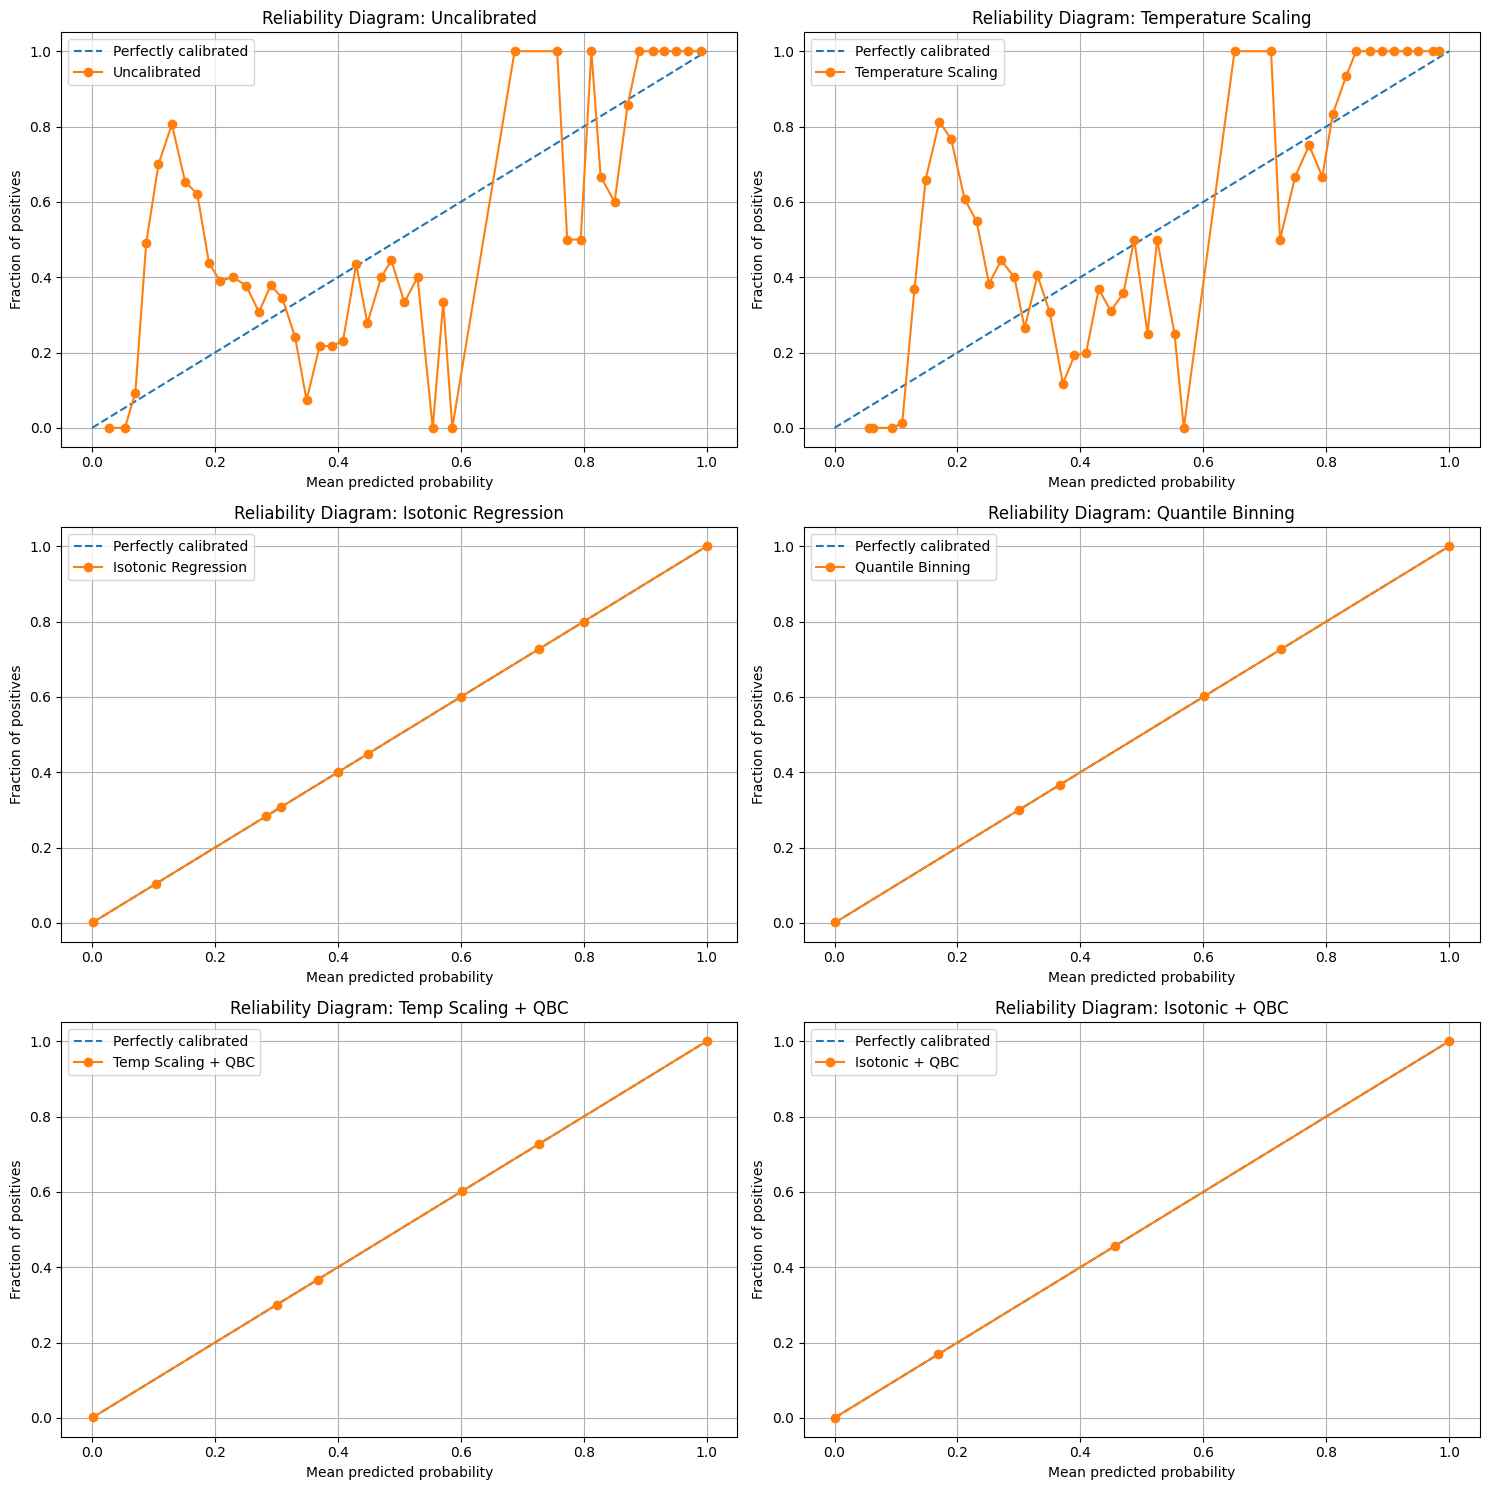

In [ ]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

def plot_reliability_diagram(y_true, y_prob, method_name, ax, n_bins=10):
    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=n_bins)
    ax.plot([0, 1], [0, 1], linestyle='--', label='Perfectly calibrated')
    ax.plot(prob_pred, prob_true, marker='o', label=method_name)
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction of positives')
    ax.set_title(f'Reliability Diagram: {method_name}')
    ax.legend()
    ax.grid(True)

fig, axes = plt.subplots(3, 2, figsize=(15, 15))
axes = axes.flatten()

# Uncalibrated
plot_reliability_diagram(y_val, y_prob, 'Uncalibrated', axes[0], n_bins=50)

# Temperature Scaling
plot_reliability_diagram(y_val, y_prob_ts, 'Temperature Scaling', axes[1], n_bins=50)

# Isotonic Regression
plot_reliability_diagram(y_val, y_prob_iso, 'Isotonic Regression', axes[2], n_bins=50)

# Quantile Binning (BBQ proxy)
plot_reliability_diagram(y_val, y_prob_qbc, 'Quantile Binning', axes[3], n_bins=50)

# Hybrid Temperature Scaling + Quantile Binning
plot_reliability_diagram(y_val, y_prob_ts_qbc_hybrid, 'Temp Scaling + QBC', axes[4], n_bins=50)

# Hybrid Isotonic Regression + Quantile Binning
plot_reliability_diagram(y_val, y_prob_iso_qbc_hybrid, 'Isotonic + QBC', axes[5], n_bins=50)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from sklearn.isotonic import IsotonicRegression
from scipy.optimize import minimize

# Helper function to calculate Negative Log Likelihood (NLL) for Temperature Scaling
def _nll_loss(t, y_prob, y_true):
    # Apply temperature scaling to logits (inverse of sigmoid)
    # Assuming y_prob are already sigmoid outputs, we need to inverse them to get logits.
    # y_prob = 1 / (1 + exp(-logits))
    # logits = -log(1/y_prob - 1)

    # To avoid log(0) or log(inf), clamp probabilities
    y_prob = np.clip(y_prob, 1e-10, 1 - 1e-10)
    logits = np.log(y_prob / (1 - y_prob))

    scaled_logits = logits / t
    scaled_probs = 1 / (1 + np.exp(-scaled_logits))

    # Calculate binary cross-entropy (NLL)
    loss = -np.mean(y_true * np.log(scaled_probs) + (1 - y_true) * np.log(1 - scaled_probs))
    return loss

def calibrate_temperature_scaling(y_prob, y_true):
    """
    Calibrates probabilities using Temperature Scaling.
    Finds optimal T by minimizing NLL on y_true and y_prob.
    """
    # Initial guess for T (usually 1)
    t_init = np.array([1.0])

    # Minimize NLL to find optimal T
    # Bounds (0.1, 10.0) to prevent T from being too small or too large, or negative.
    res = minimize(_nll_loss, t_init, args=(y_prob, y_true), method='L-BFGS-B', bounds=[(0.1, 10.0)])

    optimal_t = res.x[0]

    # Apply temperature to logits
    y_prob_clipped = np.clip(y_prob, 1e-10, 1 - 1e-10)
    logits = np.log(y_prob_clipped / (1 - y_prob_clipped))
    calibrated_logits = logits / optimal_t
    calibrated_prob = 1 / (1 + np.exp(-calibrated_logits))

    return calibrated_prob, optimal_t

def calibrate_isotonic_regression(y_prob, y_true):
    """
    Calibrates probabilities using Isotonic Regression.
    """
    ir = IsotonicRegression(out_of_bounds="clip")
    ir.fit(y_prob, y_true)
    calibrated_prob = ir.transform(y_prob)
    return calibrated_prob

def calibrate_quantile_binning(y_prob, y_true, n_bins=10):
    """
    Calibrates probabilities using Quantile Binning (a simple binning calibration).
    Divides the probability space into bins based on quantiles.
    """
    # Create bins based on quantiles of y_prob
    quantiles = np.linspace(0, 1, n_bins + 1)
    bins = np.quantile(y_prob, quantiles)
    bins[0] = -np.inf # Ensure first bin captures values down to 0
    bins[-1] = np.inf # Ensure last bin captures values up to 1

    calibrated_prob = np.zeros_like(y_prob, dtype=float)

    for i in range(n_bins):
        # Get indices for the current bin
        idx = (y_prob >= bins[i]) & (y_prob < bins[i+1])

        if np.any(idx):
            # Calculate the mean observed frequency in the bin
            mean_true = np.mean(y_true[idx])
            # Assign this mean as the calibrated probability for all items in the bin
            calibrated_prob[idx] = mean_true

    # Handle cases where bins might be empty due to identical probabilities
    # or if some y_prob values fall outside defined bins (though quantiles should prevent this)
    # A simple fallback is to use the uncalibrated probability or nearest bin mean.
    # For now, default to original if no bin found (should not happen with inf bounds)
    calibrated_prob[np.isnan(calibrated_prob)] = y_prob[np.isnan(calibrated_prob)] # Fallback

    return calibrated_prob


print("Calibration helper functions defined for CV4.")

Calibration helper functions defined for CV4.


### Applying and Evaluating Calibration Techniques for CV3

### Reliability Diagrams for CV3

A reliability diagram plots the predicted probability against the observed frequency of positive outcomes. A perfectly calibrated model would have its points fall along the diagonal line.

In [ ]:
print(f"\n=== Original Uncalibrated Metrics for CV{current_fold_index + 1} ===")
print(f"Original Brier Score: {brier:.4f}")
print(f"Original ECE: {ece:.4f}")

results_cv3 = []

# --- 1. Temperature Scaling ---
print("\n--- Applying Temperature Scaling ---")
y_prob_ts, optimal_t = calibrate_temperature_scaling(y_prob, y_val)
brier_ts = brier_score_loss(y_val, y_prob_ts)
ece_ts = expected_calibration_error(y_val, y_prob_ts)
results_cv3.append({
    'Method': 'Temperature Scaling',
    'Brier Score': brier_ts,
    'ECE': ece_ts
})
print(f"Optimal Temperature (T): {optimal_t:.4f}")
print(f"Temperature Scaling - Brier Score: {brier_ts:.4f}")
print(f"Temperature Scaling - ECE: {ece_ts:.4f}")

# --- 2. Isotonic Regression ---
print("\n--- Applying Isotonic Regression ---")
y_prob_iso = calibrate_isotonic_regression(y_prob, y_val)
brier_iso = brier_score_loss(y_val, y_prob_iso)
ece_iso = expected_calibration_error(y_val, y_prob_iso)
results_cv3.append({
    'Method': 'Isotonic Regression',
    'Brier Score': brier_iso,
    'ECE': ece_iso
})
print(f"Isotonic Regression - Brier Score: {brier_iso:.4f}")
print(f"Isotonic Regression - ECE: {ece_iso:.4f}")

# --- 3. Quantile Binning Calibration ('BBQ' proxy) ---
print("\n--- Applying Quantile Binning Calibration (BBQ proxy) ---")
y_prob_qbc = calibrate_quantile_binning(y_prob, y_val, n_bins=10)
brier_qbc = brier_score_loss(y_val, y_prob_qbc)
ece_qbc = expected_calibration_error(y_val, y_prob_qbc)
results_cv3.append({
    'Method': 'Quantile Binning (BBQ proxy)',
    'Brier Score': brier_qbc,
    'ECE': ece_qbc
})
print(f"Quantile Binning - Brier Score: {brier_qbc:.4f}")
print(f"Quantile Binning - ECE: {ece_qbc:.4f}")

# --- 4. Hybrid: Temperature Scaling + Quantile Binning ---
print("\n--- Applying Hybrid: Temperature Scaling + Quantile Binning ---")
# First, apply temperature scaling
y_prob_ts_hybrid, _ = calibrate_temperature_scaling(y_prob, y_val)
# Then, apply quantile binning to the temperature-scaled probabilities
y_prob_ts_qbc_hybrid = calibrate_quantile_binning(y_prob_ts_hybrid, y_val, n_bins=10)
brier_ts_qbc_hybrid = brier_score_loss(y_val, y_prob_ts_qbc_hybrid)
ece_ts_qbc_hybrid = expected_calibration_error(y_val, y_prob_ts_qbc_hybrid)
results_cv3.append({
    'Method': 'Temp Scaling + Quantile Binning',
    'Brier Score': brier_ts_qbc_hybrid,
    'ECE': ece_ts_qbc_hybrid
})
print(f"Hybrid (Temp+QBC) - Brier Score: {brier_ts_qbc_hybrid:.4f}")
print(f"Hybrid (Temp+QBC) - ECE: {ece_ts_qbc_hybrid:.4f}")

# --- 5. Hybrid: Isotonic Regression + Quantile Binning ---
print("\n--- Applying Hybrid: Isotonic Regression + Quantile Binning ---")
# First, apply isotonic regression
y_prob_iso_hybrid = calibrate_isotonic_regression(y_prob, y_val)
# Then, apply quantile binning to the isotonic-calibrated probabilities
y_prob_iso_qbc_hybrid = calibrate_quantile_binning(y_prob_iso_hybrid, y_val, n_bins=10)
brier_iso_qbc_hybrid = brier_score_loss(y_val, y_prob_iso_qbc_hybrid)
ece_iso_qbc_hybrid = expected_calibration_error(y_val, y_prob_iso_qbc_hybrid)
results_cv3.append({
    'Method': 'Isotonic + Quantile Binning',
    'Brier Score': brier_iso_qbc_hybrid,
    'ECE': ece_iso_qbc_hybrid
})
print(f"Hybrid (Isotonic+QBC) - Brier Score: {brier_iso_qbc_hybrid:.4f}")
print(f"Hybrid (Isotonic+QBC) - ECE: {ece_iso_qbc_hybrid:.4f}")

print(f"\n=== Summary of Calibration Results for CV{current_fold_index + 1} ===")
for res in results_cv3:
    print(f"Method: {res['Method']}: Brier Score={res['Brier Score']:.4f}, ECE={res['ECE']:.4f}")


=== Original Uncalibrated Metrics for CV3 ===
Original Brier Score: 0.0714
Original ECE: 0.4786

--- Applying Temperature Scaling ---
Optimal Temperature (T): 1.4597
Temperature Scaling - Brier Score: 0.0644
Temperature Scaling - ECE: 0.4575

--- Applying Isotonic Regression ---
Isotonic Regression - Brier Score: 0.0270
Isotonic Regression - ECE: 0.4660

--- Applying Quantile Binning Calibration (BBQ proxy) ---
Quantile Binning - Brier Score: 0.0424
Quantile Binning - ECE: 0.4469

--- Applying Hybrid: Temperature Scaling + Quantile Binning ---
Hybrid (Temp+QBC) - Brier Score: 0.0424
Hybrid (Temp+QBC) - ECE: 0.4469

--- Applying Hybrid: Isotonic Regression + Quantile Binning ---
Hybrid (Isotonic+QBC) - Brier Score: 0.0272
Hybrid (Isotonic+QBC) - ECE: 0.4660

=== Summary of Calibration Results for CV3 ===
Method: Temperature Scaling: Brier Score=0.0644, ECE=0.4575
Method: Isotonic Regression: Brier Score=0.0270, ECE=0.4660
Method: Quantile Binning (BBQ proxy): Brier Score=0.0424, ECE=0.

### Model Calibration for CV3 (Platt Scaling)

In [ ]:
from sklearn.linear_model import LogisticRegression

print(f"\n=== Calibrating model using Platt Scaling for CV{current_fold_index + 1} ===")

# Reshape y_prob for scikit-learn's LogisticRegression
y_prob_reshaped = y_prob.reshape(-1, 1)

# Initialize and train Platt Scaling (Logistic Regression) on the validation set predictions
# We fit it on the raw probabilities (y_prob) and the true labels (y_val)
calibrator = LogisticRegression(solver='lbfgs', C=1.0, penalty=None, tol=1e-6, max_iter=1000)
calibrator.fit(y_prob_reshaped, y_val)

# Get calibrated probabilities
y_prob_calibrated_platt = calibrator.predict_proba(y_prob_reshaped)[:, 1]

print("Calibration complete.")


=== Calibrating model using Platt Scaling for CV3 ===
Calibration complete.


In [ ]:
n

### Evaluation After Calibration for CV3

In [ ]:
print(f"\n=== Computing metrics for calibrated probabilities (Platt Scaling) for CV{current_fold_index + 1} ===")

y_pred_calibrated_platt = (y_prob_calibrated_platt >= 0.5).astype(int)

acc_cal_platt = accuracy_score(y_val, y_pred_calibrated_platt)
brier_cal_platt = brier_score_loss(y_val, y_prob_calibrated_platt)
ece_cal_platt = expected_calibration_error(y_val, y_prob_calibrated_platt)

print(f"\n=== Performance for CV{current_fold_index + 1} (Calibrated with Platt) ===")
print(f"Accuracy (Calibrated): {acc_cal_platt:.4f}")
print(f"Brier Score (Calibrated): {brier_cal_platt:.4f}")
print(f"ECE (Calibrated): {ece_cal_platt:.4f}")

print("\n=== Comparison (Uncalibrated vs. Calibrated with Platt) ===")
print(f"Original ECE: {ece:.4f}")
print(f"Calibrated ECE: {ece_cal_platt:.4f}")
print(f"Original Brier Score: {brier:.4f}")
print(f"Calibrated Brier Score: {brier_cal_platt:.4f}")


=== Computing metrics for calibrated probabilities (Platt Scaling) for CV3 ===

=== Performance for CV3 (Calibrated with Platt) ===
Accuracy (Calibrated): 0.9203
Brier Score (Calibrated): 0.0603
ECE (Calibrated): 0.4278

=== Comparison (Uncalibrated vs. Calibrated with Platt) ===
Original ECE: 0.4786
Calibrated ECE: 0.4278
Original Brier Score: 0.0714
Calibrated Brier Score: 0.0603


### Reliability Diagrams for CV3

A reliability diagram plots the predicted probability against the observed frequency of positive outcomes. A perfectly calibrated model would have its points fall along the diagonal line.

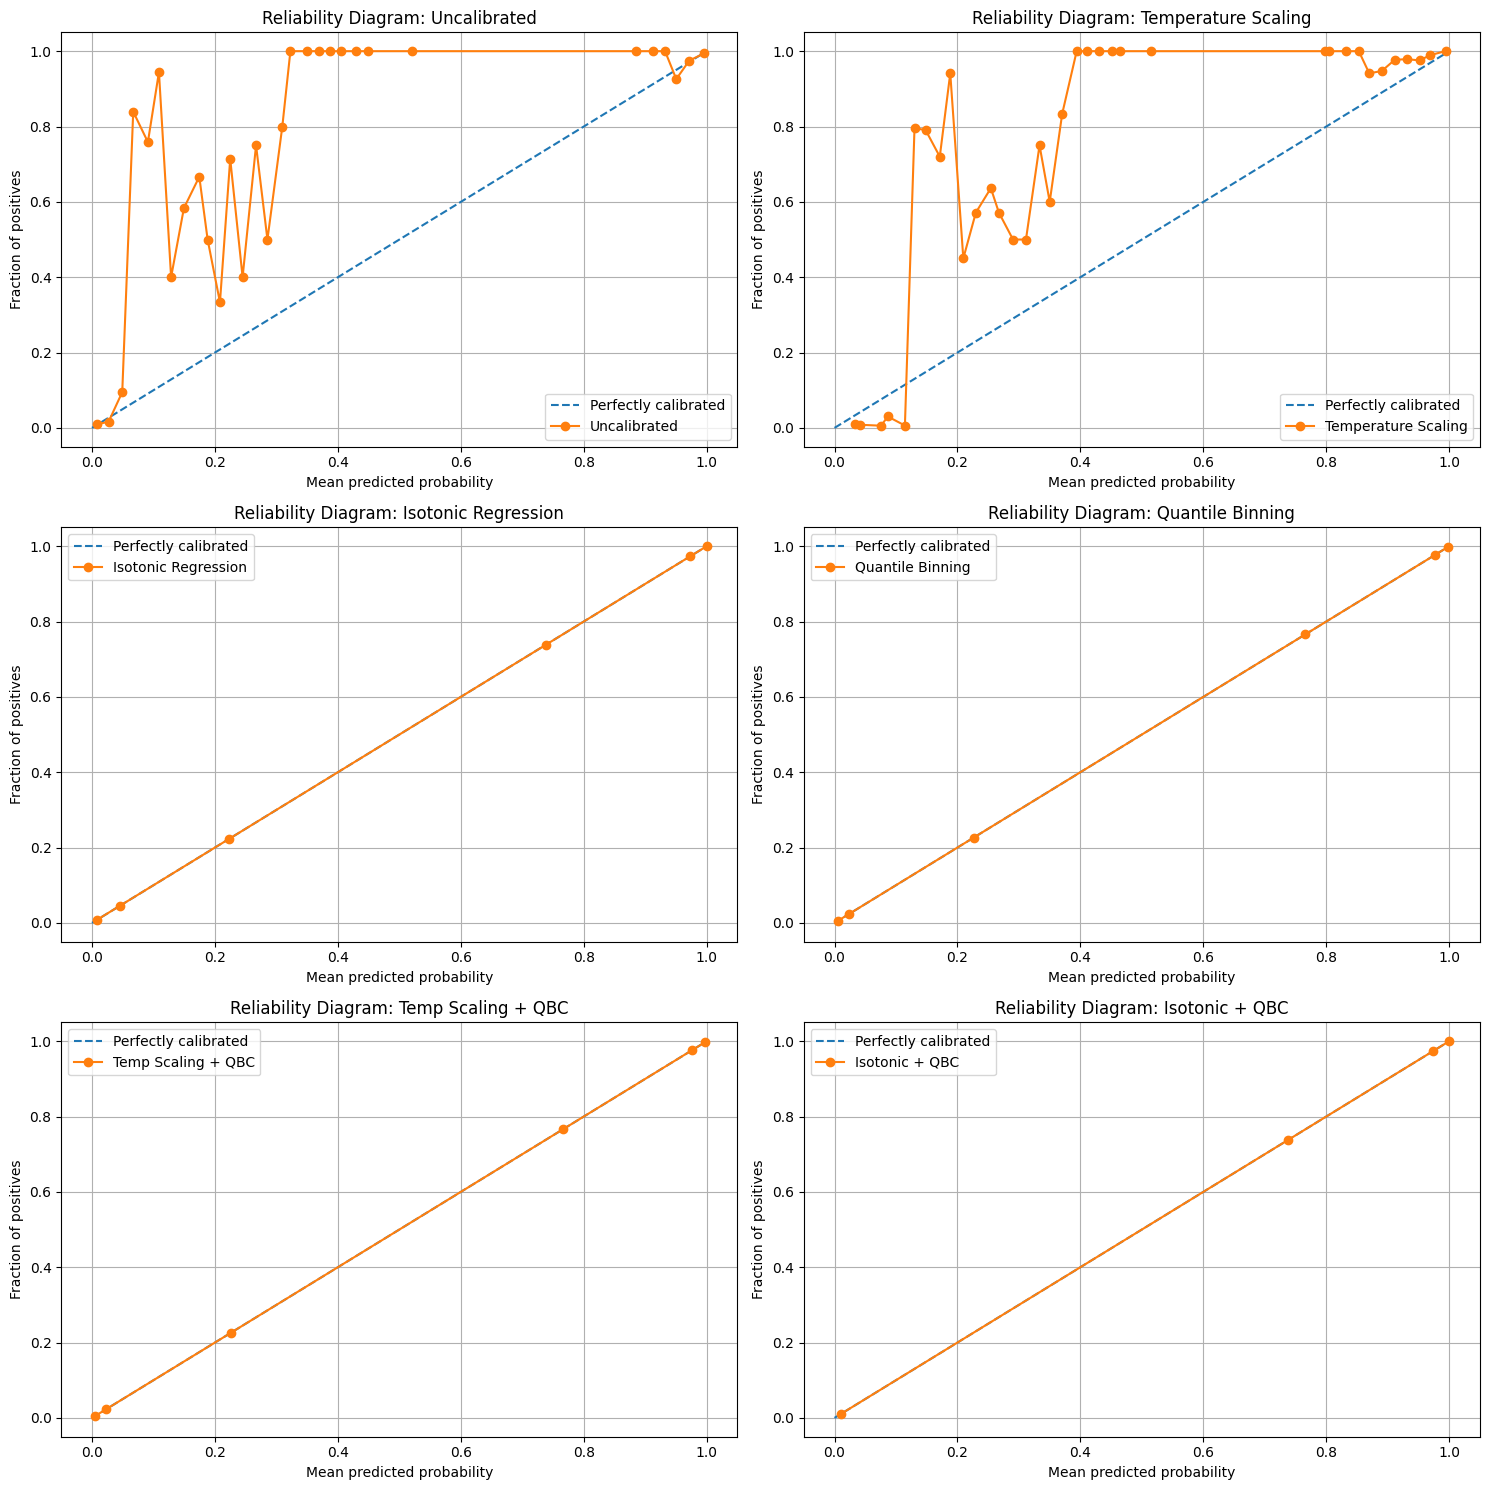

In [ ]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

def plot_reliability_diagram(y_true, y_prob, method_name, ax, n_bins=10):
    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=n_bins)
    ax.plot([0, 1], [0, 1], linestyle='--', label='Perfectly calibrated')
    ax.plot(prob_pred, prob_true, marker='o', label=method_name)
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction of positives')
    ax.set_title(f'Reliability Diagram: {method_name}')
    ax.legend()
    ax.grid(True)

fig, axes = plt.subplots(3, 2, figsize=(15, 15))
axes = axes.flatten()

# Uncalibrated
plot_reliability_diagram(y_val, y_prob, 'Uncalibrated', axes[0], n_bins=50)

# Temperature Scaling
plot_reliability_diagram(y_val, y_prob_ts, 'Temperature Scaling', axes[1], n_bins=50)

# Isotonic Regression
plot_reliability_diagram(y_val, y_prob_iso, 'Isotonic Regression', axes[2], n_bins=50)

# Quantile Binning (BBQ proxy)
plot_reliability_diagram(y_val, y_prob_qbc, 'Quantile Binning', axes[3], n_bins=50)

# Hybrid Temperature Scaling + Quantile Binning
plot_reliability_diagram(y_val, y_prob_ts_qbc_hybrid, 'Temp Scaling + QBC', axes[4], n_bins=50)

# Hybrid Isotonic Regression + Quantile Binning
plot_reliability_diagram(y_val, y_prob_iso_qbc_hybrid, 'Isotonic + QBC', axes[5], n_bins=50)

plt.tight_layout()
plt.show()

In [ ]:
# =====================================================
# 4-Fold Cross-Validation using CNN-LSTM (Manual CV Control) CV4
# =====================================================

import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, brier_score_loss
import os
from datetime import datetime

# --------------------------------------------
# Base path and folds
# --------------------------------------------
base_partitioned_path = r"/content/drive/My Drive/Vibration June 2026/CNN LSTM"
num_folds = 4

# --------------------------------------------
# Helper: statistical features
# --------------------------------------------
def calculate_statistical_features(vibration_data):
    vibration_data = pd.Series(vibration_data).dropna()
    if vibration_data.empty:
        return np.array([0.0, 0.0, 0.0, 0.0])
    peak_to_peak = np.ptp(vibration_data)
    kurtosis = vibration_data.kurtosis() if len(vibration_data) > 3 else 0.0
    skewness = vibration_data.skew() if len(vibration_data) > 2 else 0.0
    variance = vibration_data.var() if len(vibration_data) > 1 else 0.0
    return np.array([peak_to_peak, kurtosis, skewness, variance])

# --------------------------------------------
# Dataset generator
# --------------------------------------------
def dataset_generator(file_list, global_max_timesteps, global_max_features):
    for f in file_list:
        try:
            df = pd.read_excel(f, skiprows=1, header=None)
            df = df.apply(pd.to_numeric, errors='coerce').fillna(0)
            sequence_label = int(df.iloc[0, 0])
            amplitude_data = df.iloc[:, 1].astype(float)
            other_features_data = df.iloc[:, 2:4].astype(float)
            extra_features = calculate_statistical_features(amplitude_data)
            extra_features_expanded = np.tile(extra_features, (len(amplitude_data), 1))
            sample = np.hstack((amplitude_data.values.reshape(-1, 1),
                                other_features_data.values,
                                extra_features_expanded))
            # Pad/truncate
            if sample.shape[0] < global_max_timesteps:
                row_padding = np.zeros((global_max_timesteps - sample.shape[0], sample.shape[1]))
                sample = np.vstack((sample, row_padding))
            elif sample.shape[0] > global_max_timesteps:
                sample = sample[:global_max_timesteps, :]
            # Pad features if needed
            if sample.shape[1] < global_max_features:
                col_padding = np.zeros((sample.shape[0], global_max_features - sample.shape[1]))
                sample = np.hstack((sample, col_padding))
            elif sample.shape[1] > global_max_features:
                sample = sample[:, :global_max_features]
            yield sample.astype(np.float32), sequence_label
        except Exception as e:
            print(f"Error loading {f}: {e}")
            continue

def make_tf_dataset(file_list, global_max_timesteps, global_max_features, batch_size=64, shuffle=True):
    output_signature = (
        tf.TensorSpec(shape=(global_max_timesteps, global_max_features), dtype=tf.float32),
        tf.TensorSpec(shape=(), dtype=tf.int32)
    )
    ds = tf.data.Dataset.from_generator(
        lambda: dataset_generator(file_list, global_max_timesteps, global_max_features),
        output_signature=output_signature
    )
    if shuffle:
        ds = ds.shuffle(buffer_size=len(file_list))
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

# --------------------------------------------
# CNN-LSTM model
# --------------------------------------------
def build_model(input_shape,
                conv_filters=32,
                kernel_size=5,
                pool_size=2,
                lstm_units=64,
                dense_units=32,
                dropout_rate=0.3,
                learning_rate=1e-4):
    print("\n=== Building CNN-LSTM model ===")
    model = models.Sequential()
    model.add(Input(shape=input_shape))
    model.add(layers.Normalization())
    model.add(layers.Conv1D(conv_filters, kernel_size, activation='relu'))
    model.add(layers.MaxPooling1D(pool_size=pool_size))
    model.add(layers.Dropout(dropout_rate))
    model.add(layers.LSTM(lstm_units, dropout=dropout_rate, recurrent_dropout=0.2))
    model.add(layers.Dense(dense_units, activation='relu'))
    model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(1, activation='sigmoid'))
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate, clipnorm=1.0)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

# --------------------------------------------
# Calibration Error helper
# --------------------------------------------
def expected_calibration_error(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins+1)
    ece = 0.0
    for i in range(n_bins):
        idx = (y_prob >= bins[i]) & (y_prob < bins[i+1])
        if np.any(idx):
            acc_bin = np.mean(y_true[idx] == (y_prob[idx] >= 0.5))
            conf_bin = np.mean(y_prob[idx])
            ece += np.sum(idx) * abs(acc_bin - conf_bin)
    return ece / len(y_true)

# --------------------------------------------
# Manual CV control
# --------------------------------------------
current_fold_index = 3  # Change 0–3 for CV1–CV4
print(f"\n=== Running CV{current_fold_index + 1} ===")

cv_splits = {
    0: {"train": ["Fold1", "Fold2", "Fold3"], "val": ["Fold4"]},
    1: {"train": ["Fold1", "Fold2", "Fold4"], "val": ["Fold3"]},
    2: {"train": ["Fold1", "Fold3", "Fold4"], "val": ["Fold2"]},
    3: {"train": ["Fold2", "Fold3", "Fold4"], "val": ["Fold1"]},
}

train_folds = cv_splits[current_fold_index]["train"]
val_folds   = cv_splits[current_fold_index]["val"]

train_files, val_files = [], []
for fold in train_folds:
    fold_path = os.path.join(base_partitioned_path, fold)
    train_files.extend([os.path.join(fold_path, f) for f in os.listdir(fold_path) if f.endswith(('.xls', '.xlsx'))])

for fold in val_folds:
    fold_path = os.path.join(base_partitioned_path, fold)
    val_files.extend([os.path.join(fold_path, f) for f in os.listdir(fold_path) if f.endswith(('.xls', '.xlsx'))])

print(f"Training folds: {train_folds}, Validation fold: {val_folds}")
print(f"Train files: {len(train_files)}, Validation files: {len(val_files)}")

# --------------------------------------------
# Determine global max timesteps/features
# --------------------------------------------
print("\n=== Determining global max timesteps/features ===")
temp_raw_data_shapes = []
for f in train_files + val_files:
    try:
        df = pd.read_excel(f, skiprows=1, header=None).apply(pd.to_numeric, errors='coerce').fillna(0)
        amplitude_data_temp = df.iloc[:, 1].astype(float)
        other_features_data_temp = df.iloc[:, 2:4].astype(float)
        extra_features_temp = calculate_statistical_features(amplitude_data_temp)
        combined_feature_count = other_features_data_temp.shape[1] + 1 + len(extra_features_temp)
        temp_raw_data_shapes.append((df.shape[0], combined_feature_count))
    except Exception as e:
        print(f"Warning: {f} shape error: {e}")
        continue

global_max_timesteps = min(max(s[0] for s in temp_raw_data_shapes), 1000)
global_max_features  = max(s[1] for s in temp_raw_data_shapes)
print(f"Global max timesteps: {global_max_timesteps}, Global max features: {global_max_features}")

# --------------------------------------------
# Build streaming datasets
# --------------------------------------------
print("\n=== Preparing streaming datasets ===")
train_ds = make_tf_dataset(train_files, global_max_timesteps, global_max_features, batch_size=64, shuffle=True)
val_ds   = make_tf_dataset(val_files, global_max_timesteps, global_max_features, batch_size=64, shuffle=False)

# --------------------------------------------
# Train model
# --------------------------------------------
model = build_model(input_shape=(global_max_timesteps, global_max_features))
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

batch_size = 64  # keep this consistent everywhere

print("\n=== Model training started ===")
steps_per_epoch = max(1, len(train_files) // batch_size)
validation_steps = max(1, len(val_files) // batch_size)

history = model.fit(
    train_ds.repeat(),
    epochs=20,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_ds.repeat(),
    validation_steps=validation_steps,
    callbacks=[early_stop]
)

print("\n=== Model training completed ===")

# --------------------------------------------
# Predictions and Evaluation
# --------------------------------------------
print("\n=== Generating predictions on validation fold ===")
y_prob = model.predict(val_ds).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print("\n=== Collecting true labels from validation dataset ===")
y_val = np.concatenate([y.numpy() for _, y in val_ds], axis=0)

print("\n=== Computing metrics ===")
acc = accuracy_score(y_val, y_pred)

# Healthy = 0, Faulty = 1
prec_H = precision_score(y_val, y_pred, pos_label=0)
prec_F = precision_score(y_val, y_pred, pos_label=1)
rec_H  = recall_score(y_val, y_pred, pos_label=0)
rec_F  = recall_score(y_val, y_pred, pos_label=1)
f1     = f1_score(y_val, y_pred, pos_label=1)  # F1 for faulty class
brier  = brier_score_loss(y_val, y_prob)
ece    = expected_calibration_error(y_val, y_prob)

print(f"\n=== Performance for CV{current_fold_index + 1} ===")
print(f"Accuracy: {acc:.4f}")
print(f"Precision (Healthy=0): {prec_H:.4f}")
print(f"Precision (Faulty=1): {prec_F:.4f}")
print(f"Recall (Healthy=0): {rec_H:.4f}")
print(f"Recall (Faulty=1): {rec_F:.4f}")
print(f"F1 Score (Faulty=1): {f1:.4f}")
print(f"Brier Score: {brier:.4f}")
print(f"ECE: {ece:.4f}")

# --------------------------------------------
# Clear session after each fold
# --------------------------------------------
print("\n=== Clearing TensorFlow session ===")
tf.keras.backend.clear_session()

# Keep these variables for calibration in Cell 3
print("\n=== Variables saved for calibration ===")
print(f"y_prob shape: {y_prob.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"y_pred shape: {y_pred.shape}")


=== Running CV4 ===
Training folds: ['Fold2', 'Fold3', 'Fold4'], Validation fold: ['Fold1']
Train files: 7680, Validation files: 2560

=== Determining global max timesteps/features ===
Global max timesteps: 1000, Global max features: 7

=== Preparing streaming datasets ===

=== Building CNN-LSTM model ===

=== Model training started ===
Epoch 1/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 1966s 7s/step - accuracy: 0.5671 - loss: 0.6818 - val_accuracy: 0.7559 - val_loss: 0.5876
Epoch 2/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 1634s 7s/step - accuracy: 0.6854 - loss: 0.5853 - val_accuracy: 0.7691 - val_loss: 0.5034
Epoch 3/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 1631s 7s/step - accuracy: 0.7664 - loss: 0.5009 - val_accuracy: 0.8109 - val_loss: 0.4307
Epoch 4/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 1618s 7s/step - accuracy: 0.8201 - loss: 0.4172 - val_accuracy: 0.8727 - val_loss: 0.3304
Epoch 5/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 1613s 7s/step - accuracy: 0.8646 - loss: 0.3307 - val_accuracy: 0.9113 - val_loss: 0.2784
Epoch 6/20

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



=== Computing metrics ===

=== Performance for CV4 ===
Accuracy: 0.9113
Precision (Healthy=0): 0.8494
Precision (Faulty=1): 1.0000
Recall (Healthy=0): 1.0000
Recall (Faulty=1): 0.8227
F1 Score (Faulty=1): 0.9027
Brier Score: 0.0789
ECE: 0.5043

=== Clearing TensorFlow session ===
